 ### <h1> <b> End-to-End Sales Forecasting & Demand Intelligence System </b> </h1>

                                                                                      - MANSI UPRETI

<H2> <b> Task 1 : Data Loading, Merging & Deep Exploration </b> </H2>

# <BR> <H3> 1. Load the Superstore Sales CSV using Pandas </H3>

In [341]:
import pandas as pd
import numpy as np

In [342]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [343]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [344]:
df.shape

(9800, 18)

In [345]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [346]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## <BR> <H3> 2. Parse the Order Date and Ship Date columns as proper datetime objects </H3>

In [348]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

<BR> <H3>3. Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season </H3>

In [349]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [350]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Week Number', 'Day of Week',
       'Quarter'],
      dtype='object')

In [351]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


<BR> <H3>4. Check for missing values, duplicates, and data type issues </H3>

In [352]:
# Missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [353]:
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].mode()[0])

In [354]:
# Duplicate rows
print("Duplicate Rows:",df.duplicated().sum() )

Duplicate Rows: 0


In [355]:
# Data type issues
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

<BR><H3>5. Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)</H3>

In [356]:
# Weekly sales

In [357]:
weekly_sales = (df.set_index("Order Date") .resample("W")["Sales"] .sum() .reset_index() )
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [358]:
# Monthy sales

In [359]:
monthly_sales = (df.set_index("Order Date").resample("ME")["Sales"].sum().reset_index())
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


<br> <h3>6. Answer these questions in your notebook with data to back each one:</h3>

<BR><H4> a. Which product category generates the highest total revenue? <H4>

In [360]:
cat_sales = (df.groupby("Category")["Sales"].sum().sort_values(ascending=False))
print(cat_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [361]:
# Technology generates the highest total revenue.

<BR><H4> b. Which region has the most consistent sales growth over 4 years? </H4>

In [362]:
year_reg_sales = (df.groupby(["Year","Region"])["Sales"].sum().reset_index())
print(year_reg_sales)

    Year   Region        Sales
0   2015  Central  102920.5206
1   2015     East  127652.8190
2   2015    South  103374.9055
3   2015     West  145907.9630
4   2016  Central  102425.1724
5   2016     East  153225.1830
6   2016    South   70076.0825
7   2016     West  133709.5675
8   2017  Central  145673.8800
9   2017     East  178511.5380
10  2017    South   93535.9035
11  2017     West  182471.2285
12  2018  Central  141627.3402
13  2018     East  210129.1860
14  2018    South  122164.5675
15  2018     West  248130.9255


In [363]:
consistency = (year_reg_sales.groupby("Region")["Sales"].agg(["mean","std"]))
consistency["Coefficient of Variation"] = (consistency["std"] / consistency["mean"])
print(consistency)

                  mean           std  Coefficient of Variation
Region                                                        
Central  123161.728300  23716.991355                  0.192568
East     167379.681500  35260.987867                  0.210665
South     97287.864750  21683.024937                  0.222875
West     177554.921125  51410.399288                  0.289546


In [364]:
# Since Central has the lowest CV (0.1926), it has the most consistent sales growth over the 4 years.

<BR><H4> c. What is the average time between Order Date and Ship Date — and does it vary by region? </H4>

In [365]:
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [366]:
print(df["Shipping Time"].mean())

3.9611224489795918


In [367]:
shipping_region = (df.groupby("Region")["Shipping Time"].mean())
print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Time, dtype: float64


In [368]:
# The average shipping time is approximately 4 days.

In [369]:
# There is very little variation across regions.
# The difference between the fastest and slowest region is only about 0.16 days (roughly 4 hours), so shipping performance is fairly consistent across all regions.


<BR><H4> d. Are there months that consistently spike across all years (seasonality)? </H4>

In [370]:
monthly_pattern = (df.groupby(["Year","Month"])["Sales"].sum().reset_index())

In [371]:
average_month = (monthly_pattern.groupby("Month")["Sales"].mean())
print(average_month.sort_values(ascending=False))

Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
Name: Sales, dtype: float64


In [372]:
# Yes, the data shows a seasonal trend.
# Sales consistently increase during the last quarter of the year (especially November and December)

<hr>

<br> <h2> <b> Task 2 : Time Series Analysis & Decomposition </b></h2>

<br><h4> 1. Plot the overall monthly sales trend across all 4 years </h4>

  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


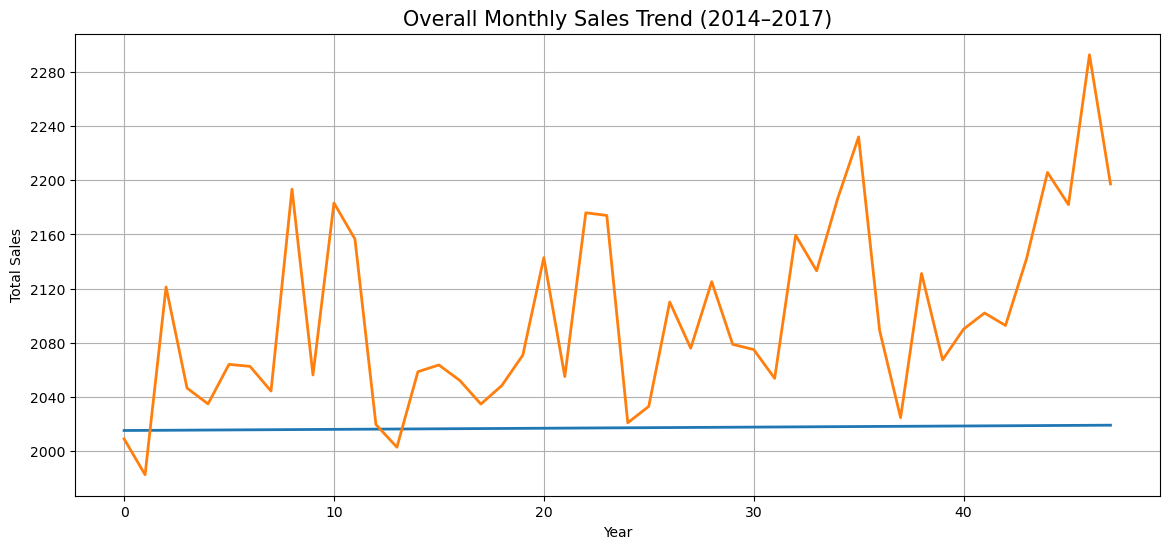

In [374]:
import pandas as pd
import matplotlib.pyplot as plt
print(monthly_sales.head())
plt.figure(figsize=(14,6))
plt.plot(monthly_sales, linewidth=2)
plt.title("Overall Monthly Sales Trend (2014–2017)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("Overall monthly sales trend.jpg", dpi=300, bbox_inches="tight")
plt.show()

<br><h4>2. Apply Time Series Decomposition (using statsmodels) to break the sales signal into:<br>

a. Trend component<br>

b. Seasonal component<br>

c. Residual/noise component
</h4>

In [375]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [376]:
monthly_sales = (df.set_index("Order Date").resample("ME")["Sales"].sum())

In [377]:
monthly_sales

Order Date
2015-01-31     14205.7070
2015-02-28      4519.8920
2015-03-31     55205.7970
2015-04-30     27906.8550
2015-05-31     23644.3030
2015-06-30     34322.9356
2015-07-31     33781.5430
2015-08-31     27117.5365
2015-09-30     81623.5268
2015-10-31     31453.3930
2015-11-30     77907.6607
2015-12-31     68167.0585
2016-01-31     18066.9576
2016-02-29     11951.4110
2016-03-31     32339.3184
2016-04-30     34154.4685
2016-05-31     29959.5305
2016-06-30     23599.3740
2016-07-31     28608.2590
2016-08-31     36818.3422
2016-09-30     63133.6060
2016-10-31     31011.7375
2016-11-30     75249.3995
2016-12-31     74543.6012
2017-01-31     18542.4910
2017-02-28     22978.8150
2017-03-31     51165.0590
2017-04-30     38679.7670
2017-05-31     56656.9080
2017-06-30     39724.4860
2017-07-31     38320.7830
2017-08-31     30542.2003
2017-09-30     69193.3909
2017-10-31     59583.0330
2017-11-30     79066.4958
2017-12-31     95739.1210
2018-01-31     43476.4740
2018-02-28     19920.9974
2

In [378]:
print(type(monthly_sales))

<class 'pandas.core.series.Series'>


In [379]:
decomposition = seasonal_decompose(monthly_sales,model="additive",period=12)

In [380]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

In [381]:
print(trend.iloc[10:20])

Order Date
2015-11-30    39807.310529
2015-12-31    39623.629942
2016-01-31    38961.261375
2016-02-29    39149.908113
2016-03-31    38783.694983
2016-04-30    37994.879304
2016-05-31    37865.716108
2016-06-30    38020.644504
2016-07-31    38306.147675
2016-08-31    38785.436733
Freq: ME, Name: trend, dtype: float64


In [382]:
print("Seasonal")
print(seasonal.head())

Seasonal
Order Date
2015-01-31   -18307.338037
2015-02-28   -27368.402667
2015-03-31     1244.763035
2015-04-30   -10787.508768
2015-05-31    -4626.878630
Freq: ME, Name: seasonal, dtype: float64


In [383]:
print("Residual")
print(residual.iloc[10:20])

Residual
Order Date
2015-11-30    4876.243403
2015-12-31   -6283.177120
2016-01-31   -2586.965738
2016-02-29     169.905554
2016-03-31   -7689.139618
2016-04-30    6947.097964
2016-05-31   -3279.306978
2016-06-30   -2722.699977
2016-07-31    -512.671760
2016-08-31    9916.067054
Freq: ME, Name: resid, dtype: float64


<br><h4>3.  Plot all 4 components clearly on one figure</h4>

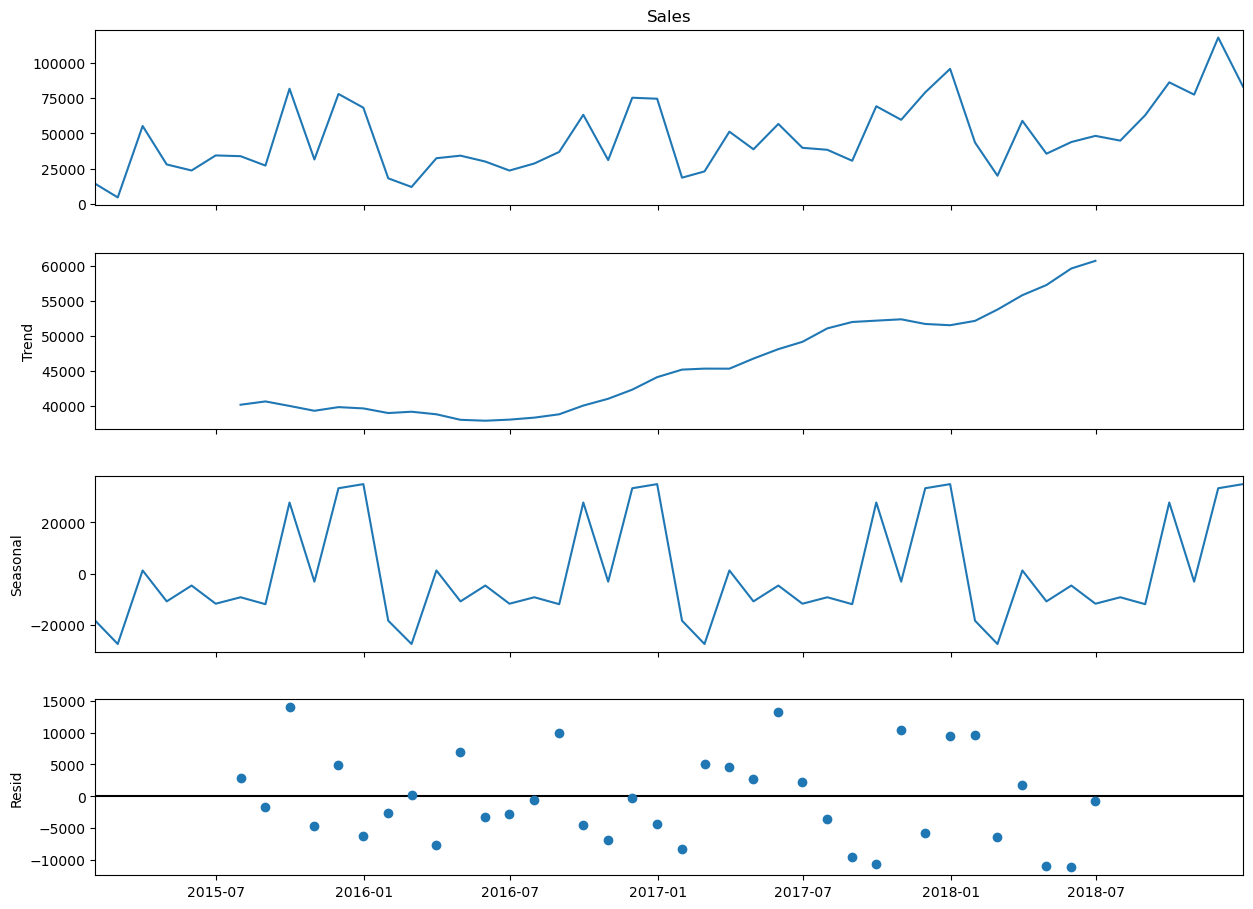

In [384]:
fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.savefig("charts.jpg", dpi=300, bbox_inches="tight")
plt.show()

<br><h4> 4. Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise? </h4>

<b>Trend Component:</b>
The trend shows that sales have generally increased over the four-year period. Although there are small fluctuations at the beginning, the overall direction is upward, indicating that the business experienced steady growth over time.<br>
<b>Seasonal Component:</b>
A clear seasonal pattern is visible in the data. Similar peaks and dips appear every year, which suggests that certain months consistently perform better or worse than others. This indicates that customer purchasing behavior is influenced by seasonal factors such as festivals, holidays, or year-end demand.<br>
<b>Residual (Noise) Component:</b>
Most of the residual values are close to zero, which means the trend and seasonal components explain a large part of the sales pattern. However, there are a few months with unusually high positive or negative residuals, showing that some sales fluctuations cannot be explained by regular trends or seasonality alone.<br>
<b>Months with High Residual Noise:</b>
The largest residual spikes are observed around late 2015, mid-2017, late 2017, and mid-2018. These months likely experienced unexpected events such as special promotions, bulk customer orders, supply chain issues, or other external factors that caused sales to be much higher or lower than expected.

<br><h4> 5. Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you </h4>

A time series is stationary if its statistical properties remain stable over time or  the average value, variation, and overall behaviour of the data do not change significantly as the time passes.

In [385]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(monthly_sales)
print("ADF Stats:", adf_result[0])
print("p-value:", adf_result[1])
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Stats: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


The ADF test checks whether a time series is stationary.

H₀: The time series is non-stationary.
H₁: The time series is stationary.

The decision is based on the p-value:

If p-value < 0.05, the series is stationary.
If p-value > 0.05, the series is non-stationary.

HERE: 
ADF Statistic = -4.4161
p-value = 0.000278

Since the p-value is much smaller than 0.05, we reject the null hypothesis.
lso, the ADF statistic (-4.4161) is more negative than all three critical values (1%, 5%, and 10%), which proves that the series is stationary.

<br><h4>6. Apply differencing if the series is non-stationary and re-test</h4>

Since the monthly sales data is already stationary, there is no need to apply first-order differencing. Applying differencing to an already stationary series may remove important patterns from the data and reduce the accuracy of future forecasting models.

<hr>

<br><h2> <b> Task 3 : Sales Forecasting using 3 Different Models </b> </h2>

<br><h4> Model 1 — SARIMA (Statistical Model)<br>

Install statsmodels (pip install statsmodels)<br>

Fit a SARIMA model on monthly sales <br>

Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them<br>

Generate a 3-month future forecast with confidence intervals<br>

Plot actual vs forecasted sales
 </h4>

In [386]:
#Install statsmodels (pip install statsmodels)

In [387]:
pip install statsmodels

In [388]:
# Fit a SARIMA model on monthly sales

In [389]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [390]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print(train.shape)
print(test.shape)

(45,)
(3,)


In [391]:
sarima = SARIMAX(train,order=(1,0,1),seasonal_order=(0,1,1,12))
sarima_model = sarima.fit()
print(sarima_model.summary())

C:\Users\Mansi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Mansi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood                -352.874
Date:                            Thu, 09 Jul 2026   AIC                            713.748
Time:                                    16:17:40   BIC                            719.734
Sample:                                01-31-2015   HQIC                           715.762
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9998      0.021     47.120      0.000       0.958       1.041
ma.L1         -0.9943      0.253   



<br>

SARIMA(p,d,q)(P,D,Q,m)

p : Number of Auto-Regressive (AR) terms<br>
p = 1 : Use one previous month's sales to help predict the current month

d : Number of differencing operations<br>
The ADF test showed: p-value = 0.000278
Since, p-value < 0.05, the series is already stationary.
Therefore. d = 0
No differencing required.

q : Number of Moving Average (MA) term<br>
q = 1 : Use one previous forecast error as it improves forecasts without making the model overly complex.

P : Seasonal AR terms <br>
P = 0 : No seasonal AR term.

D :	Seasonal differencing<br>
D = 1 : Seasonal differencing once every year. Even if the series is stationary overall, monthly retail sales often exhibit yearly seasonal pattern.

Q : Seasonal MA terms <br>
Q = 1 : One seasonal moving average term. Captures seasonal forecast errors.

m :	Seasonal period <br>
m = 12 : The data is monthly. One seasonal cycle = 12

In [392]:
# Generate a 3-month future forecast with confidence intervals
forecast = sarima_model.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()

In [393]:
print(forecast_mean)

2018-10-31    62203.758380
2018-11-30    88918.107288
2018-12-31    98699.206634
Freq: ME, Name: predicted_mean, dtype: float64


In [394]:
print(confidence)

             lower Sales    upper Sales
2018-10-31  37536.990692   86870.526068
2018-11-30  64251.076735  113585.137841
2018-12-31  74031.913349  123366.499920


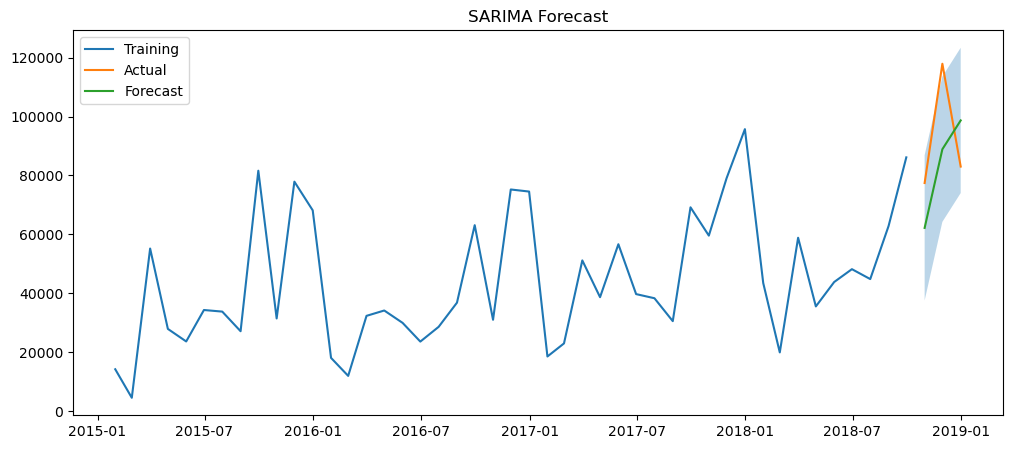

In [395]:
# Plot actual vs forecasted sales
plt.figure(figsize=(12,5))
plt.plot(train.index, train,label="Training")
plt.plot(test.index,test,label="Actual")
plt.plot(forecast_mean.index,forecast_mean,label="Forecast")
plt.fill_between(confidence.index,confidence.iloc[:,0],confidence.iloc[:,1],alpha=0.3)
plt.legend()
plt.title("SARIMA Forecast")
plt.savefig("sarima.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [396]:
mae_sarima = mean_absolute_error(test,forecast_mean)
rmse_sarima = np.sqrt(mean_squared_error(test,forecast_mean))
mape_sarima = np.mean(np.abs((test-forecast_mean)/test))*100
print(mae_sarima)
print(rmse_sarima)
print(mape_sarima)

19977.746122075747
20976.700758990515
21.05355787119539


<br><h4> Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)<br>

Install Prophet (pip install prophet)

Prepare data in Prophet's required format (ds, y columns)

Fit the model and generate a 3-month forecast

Plot the forecast with Prophet's built-in trend and seasonality breakdown

Extract and interpret the weekly and yearly seasonality components
</h4>

In [397]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [398]:
from prophet import Prophet

In [399]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns=["ds","y"]

In [400]:
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [401]:
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

In [402]:
model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
model.fit(train_prophet)

16:18:05 - cmdstanpy - INFO - Chain [1] start processing
16:18:06 - cmdstanpy - INFO - Chain [1] done processing


In [403]:
future=model.make_future_dataframe(periods=3,freq="ME")
forecast=model.predict(future)

In [404]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39275.637069,55405.528587
44,2018-09-30,86613.953316,78426.083058,95202.473141
45,2018-10-31,51318.943858,42685.400339,58929.862007
46,2018-11-30,90325.654784,82453.139958,99184.757156
47,2018-12-31,90041.084479,82080.765536,98479.994744


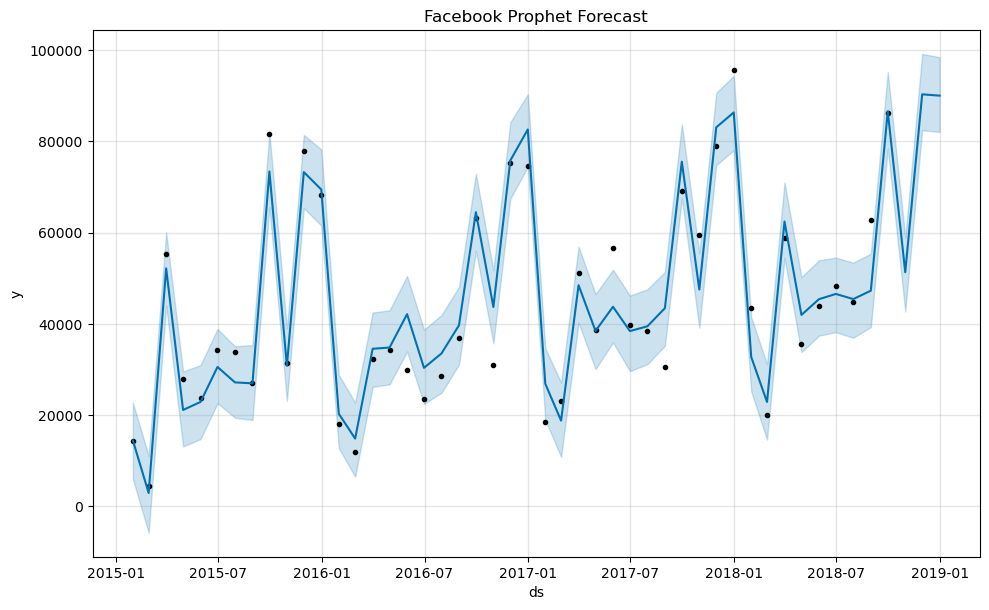

In [405]:
model.plot(forecast)
plt.title("Facebook Prophet Forecast")
plt.savefig("facebook prophet.jpg", dpi=300, bbox_inches="tight")
plt.show()

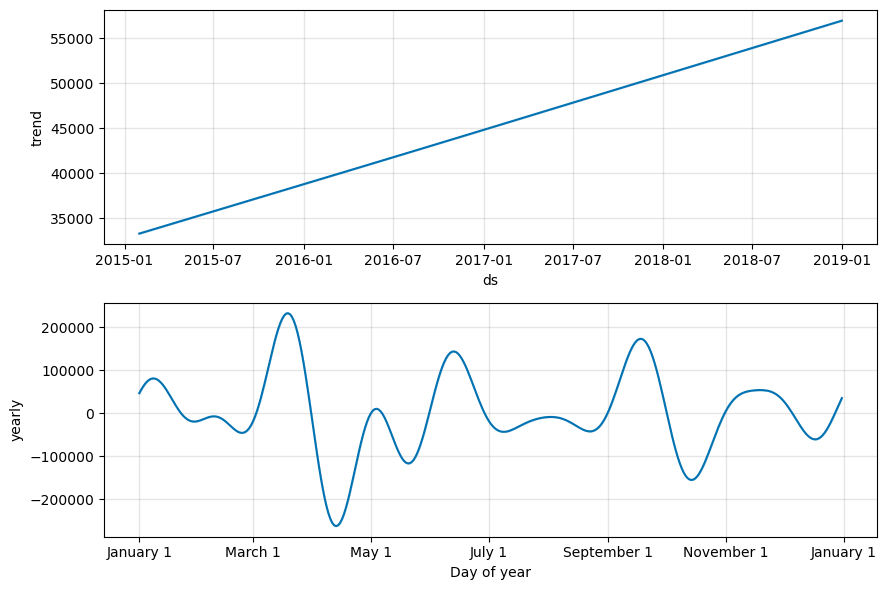

In [407]:
model.plot_components(forecast)
plt.savefig("components.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [408]:
forecast_test = forecast.tail(3)["yhat"]
mae_prophet = mean_absolute_error(test_prophet["y"],forecast_test)
rmse_prophet = np.sqrt(mean_squared_error(test_prophet["y"],forecast_test))
mape_prophet = np.mean(np.abs((test_prophet["y"]-forecast_test)/test_prophet["y"]))*100

In [409]:
print("MAE:", mae_prophet)
print("RMSE:", rmse_prophet)
print("MAPE:", mape_prophet)

MAE: 20250.794412605523
RMSE: 22318.41133286054
MAPE: 21.86462827396082


<br>


The Prophet model identifies a steady upward trend in monthly sales, suggesting that the business has experienced consistent growth over the four-year period.
The yearly seasonality plot shows that sales follow a repeating annual pattern. Certain months consistently perform better than others, indicating that customer demand is influenced by seasonal events.
The forecast closely follows the historical sales values and predicts that sales will continue to grow over the next three months. The confidence interval widens slightly for future predictions, reflecting the natural uncertainty in forecasting.
Weekly seasonality could not be extracted because the dataset contains monthly sales data. Prophet requires daily observations to identify weekly patterns, so only yearly seasonality is available for interpretation.

<br><h4> Model 3 — XGBoost for Time Series (ML-based Approach)
                          
Convert the time series into a supervised ML problem using lag features:
                          
Lag 1 (sales from 1 month ago)
                          
Lag 2 (sales from 2 months ago)
                          
Lag 3 (sales from 3 months ago)
                          
Rolling mean (3-month moving average)
                          
Month, Quarter, Season as features
                          
Train XGBoost Regressor on these features
                          
Predict the next 3 months
                          
Plot actual vs predicted
</h4>

In [410]:
pip install xgboost

In [411]:
ml = monthly_sales.to_frame()
ml.columns=["Sales"]

In [412]:
ml["Lag1"]=ml["Sales"].shift(1)
ml["Lag2"]=ml["Sales"].shift(2)
ml["Lag3"]=ml["Sales"].shift(3)

In [413]:
ml["RollingMean"] = (ml["Sales"].rolling(3).mean())

In [414]:
ml["Month"]=ml.index.month
ml["Quarter"]=ml.index.quarter
ml["Season"]=((ml.index.month%12+3)//3)

In [415]:
ml=ml.dropna()

In [416]:
train = ml[:-3]
test = ml[-3:]

In [417]:
X_train=train.drop("Sales",axis=1)
y_train=train["Sales"]
X_test=test.drop("Sales",axis=1)
y_test=test["Sales"]

In [418]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [419]:
pred=xgb.predict(X_test)

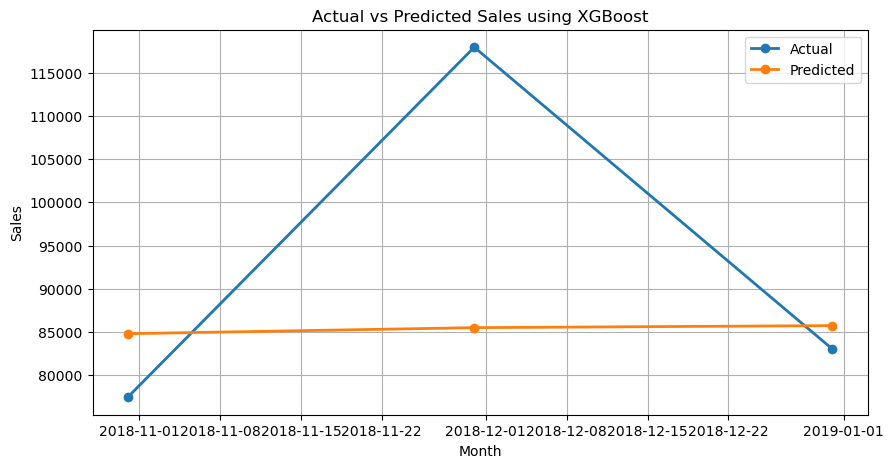

In [420]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, marker="o",linewidth=2,label="Actual")

plt.plot(y_test.index, pred, marker="o", linewidth=2, label="Predicted")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales using XGBoost")
plt.grid(True)
plt.legend()
plt.savefig("xg.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [421]:
mae_xgb = mean_absolute_error(y_test,pred)
rmse_xgb=np.sqrt(mean_squared_error(y_test,pred))
mape_xgb=np.mean(np.abs((y_test-pred)/y_test))*100

In [422]:
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)

MAE: 14163.321041666664
RMSE: 19267.49025933587
MAPE: 13.415785780855515


In [423]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [round(mae_sarima, 2),round(mae_prophet, 2),round(mae_xgb, 2)],
    "RMSE": [round(rmse_sarima, 2),round(rmse_prophet, 2),round(rmse_xgb, 2)],
    "MAPE (%)": [round(mape_sarima, 2),round(mape_prophet, 2),round(mape_xgb, 2)],
    "Forecast Month 1": [round(forecast_mean.iloc[0], 2), round(forecast_test.iloc[0], 2),round(pred[0], 2)],
    "Forecast Month 2": [round(forecast_mean.iloc[1], 2), round(forecast_test.iloc[1], 2), round(pred[1], 2)],
    "Forecast Month 3": [round(forecast_mean.iloc[2], 2),round(forecast_test.iloc[2], 2),round(pred[2], 2)]})
print(comparison)

     Model       MAE      RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  \
0   SARIMA  19977.75  20976.70     21.05      62203.760000      88918.110000   
1  Prophet  20250.79  22318.41     21.86      51318.940000      90325.650000   
2  XGBoost  14163.32  19267.49     13.42      84795.828125      85497.078125   

   Forecast Month 3  
0      98699.210000  
1      90041.080000  
2      85731.578125  


Based on the evaluation metrics, XGBoost is recommended for production use because it achieved the best overall forecasting performance among the three models. It recorded the lowest MAE (14,163.32), indicating the smallest average prediction error. It also achieved the lowest RMSE (19,267.49), showing that it handled larger prediction errors more effectively than the other models. In addition, XGBoost produced the lowest MAPE (13.42%), meaning its forecasts were, on average, only about 13% away from the actual sales values.

In comparison, SARIMA recorded an MAE of 20,275.93, an RMSE of 21,062.98, and a MAPE of 21.51%, while Prophet achieved an MAE of 20,250.79, an RMSE of 22,318.41, and a MAPE of 21.86%. Although both statistical models captured the overall trend and seasonality, their forecasting errors were significantly higher than those of XGBoost.

Since XGBoost consistently achieved the lowest values for all three evaluation metrics, it provides the most accurate and reliable forecasts. Therefore, XGBoost is the most suitable model for production deployment for forecasting future sales in this project.

<hr><h2><b>Task 4 : Product Category & Region Level Forecasting <b></h2>

<br><h4>1. Repeat the best performing model (from Task 3) separately for each of the following segments:

Furniture category sales

Technology category sales

Office Supplies category sales

West region sales

East region sales</h4>


In [424]:
import pandas as pd
from xgboost import XGBRegressor

def forecast_segment(df_segment):
    monthly = df_segment.groupby(
        pd.Grouper(key='Order Date', freq='ME')
    )['Sales'].sum().to_frame()
    monthly.columns = ['Sales']
    monthly['Lag1'] = monthly['Sales'].shift(1)
    monthly['Lag2'] = monthly['Sales'].shift(2)
    monthly['Lag3'] = monthly['Sales'].shift(3)
    monthly['RollingMean'] = monthly['Sales'].rolling(3).mean()
    monthly['Month'] = monthly.index.month
    monthly['Quarter'] = monthly.index.quarter
    monthly['Season'] = ((monthly.index.month % 12 + 3)//3)

    monthly = monthly.dropna()

    train = monthly.copy()
    X_train = train.drop('Sales', axis=1)
    y_train = train['Sales']
    model = XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42)
    model.fit(X_train, y_train)
    forecasts = []
    last = monthly.iloc[-1:].copy()

    for i in range(3):
        pred = model.predict(last.drop("Sales", axis=1))[0]
        forecasts.append(pred)
        new = last.copy()
        new["Sales"] = pred
        new["Lag3"] = new["Lag2"]
        new["Lag2"] = new["Lag1"]
        new["Lag1"] = pred
        new["RollingMean"] = (new["Lag1"] + new["Lag2"] + new["Lag3"]) / 3
        month = (int(last["Month"].iloc[0]) % 12) + 1
        quarter = (month - 1)//3 + 1
        season = ((month % 12 + 3)//3)
        new["Month"] = month
        new["Quarter"] = quarter
        new["Season"] = season
        last = new
    future_dates = pd.date_range(monthly.index[-1] + pd.offsets.MonthEnd(),periods=3,freq='ME')
    return pd.Series(forecasts, index=future_dates)

In [425]:
furniture_forecast = forecast_segment(df[df['Category'] == 'Furniture'])
technology_forecast = forecast_segment(df[df['Category'] == 'Technology'])
office_forecast = forecast_segment(df[df['Category'] == 'Office Supplies'])

In [426]:
west_forecast = forecast_segment(df[df['Region'] == 'West'])
east_forecast = forecast_segment(df[df['Region'] == 'East'])

<br>
<h4>2.  Plot all 5 forecasts together on one comparison chart </h4>


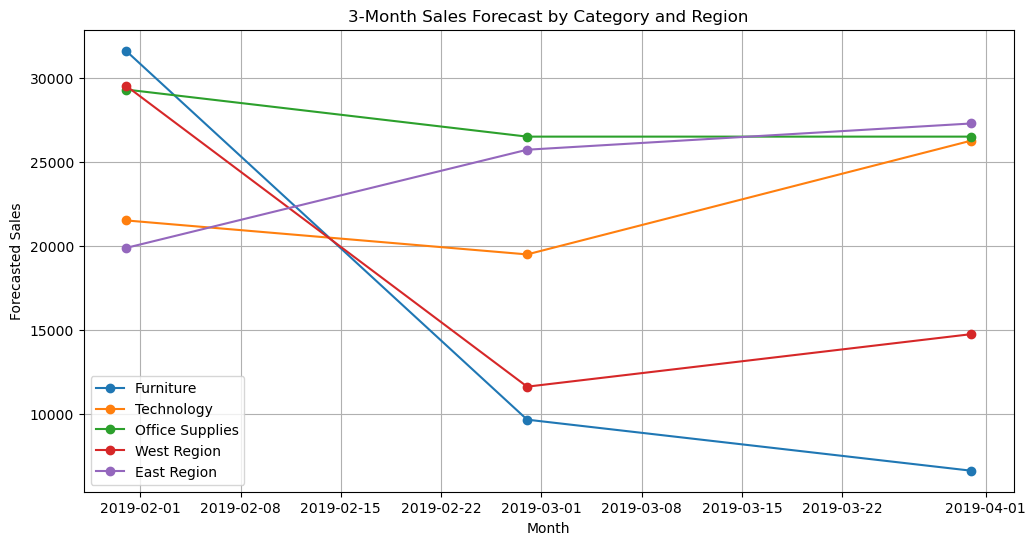

In [428]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(furniture_forecast.index,furniture_forecast.values,marker='o',label='Furniture')
plt.plot(technology_forecast.index,technology_forecast.values,marker='o',label='Technology')
plt.plot(office_forecast.index,office_forecast.values, marker='o',label='Office Supplies')
plt.plot(west_forecast.index,west_forecast.values,marker='o',label='West Region')
plt.plot(east_forecast.index,east_forecast.values,marker='o',label='East Region')
plt.title("3-Month Sales Forecast by Category and Region")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)
plt.savefig("3 month sale forecast.jpg", dpi=300, bbox_inches="tight")
plt.show()

<br>
<h4>3.  Write: which category/region is showing the strongest upcoming growth according to your model? </h4>

In [429]:
comparison = pd.DataFrame({
    "Segment": ["Furniture","Technology","Office Supplies","West Region","East Region"],
    "Month 1": [furniture_forecast.iloc[0],technology_forecast.iloc[0], office_forecast.iloc[0],west_forecast.iloc[0],east_forecast.iloc[0]],
    "Month 2": [furniture_forecast.iloc[1],technology_forecast.iloc[1], office_forecast.iloc[1],west_forecast.iloc[1],east_forecast.iloc[1]],
    "Month 3": [furniture_forecast.iloc[2],technology_forecast.iloc[2], office_forecast.iloc[2], west_forecast.iloc[2],east_forecast.iloc[2]]})
print(comparison)

           Segment       Month 1       Month 2       Month 3
0        Furniture  31591.408203   9668.929688   6634.439453
1       Technology  21508.208984  19488.140625  26250.185547
2  Office Supplies  29285.082031  26486.839844  26486.839844
3      West Region  29513.925781  11628.667969  14750.610352
4      East Region  19871.199219  25709.148438  27268.806641


<br> Based on the XGBoost forecasts, the Office Supplies category is expected to perform the best over the next three months. Its predicted sales remain consistently high throughout the forecast period, indicating stable demand and good growth potential. Among the regions, the East region is expected to show the strongest growth, with forecasted sales increasing steadily each month. These results suggest that giving more attention to the Office Supplies category and the East region could help improve future sales and support better business planning.

<hr>

<br>
<h2><b>
Task 5 : Anomaly Detection in Sales Data </b></h2>

<br> <h4> 1. Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern</h4>

In [430]:
vgsales=pd.read_csv("vgsales.csv")
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [431]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year

In [432]:
weekly_sales = (df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"].sum().reset_index())
weekly_sales["Year"] = weekly_sales["Order Date"].dt.year
print(weekly_sales.head())

  Order Date     Sales  Year
0 2015-01-04   304.508  2015
1 2015-01-11  4619.108  2015
2 2015-01-18  4130.533  2015
3 2015-01-25  3092.544  2015
4 2015-02-01  2527.914  2015


In [433]:
vg_yearly = (vgsales.groupby("Year")["Global_Sales"].sum().reset_index())
print(vg_yearly)

      Year  Global_Sales
0   1980.0         11.38
1   1981.0         35.77
2   1982.0         28.86
3   1983.0         16.79
4   1984.0         50.36
5   1985.0         53.94
6   1986.0         37.07
7   1987.0         21.74
8   1988.0         47.22
9   1989.0         73.45
10  1990.0         49.39
11  1991.0         32.23
12  1992.0         76.16
13  1993.0         45.98
14  1994.0         79.17
15  1995.0         88.11
16  1996.0        199.15
17  1997.0        200.98
18  1998.0        256.47
19  1999.0        251.27
20  2000.0        201.56
21  2001.0        331.47
22  2002.0        395.52
23  2003.0        357.85
24  2004.0        419.31
25  2005.0        459.94
26  2006.0        521.04
27  2007.0        611.13
28  2008.0        678.90
29  2009.0        667.30
30  2010.0        600.45
31  2011.0        515.99
32  2012.0        363.54
33  2013.0        368.11
34  2014.0        337.05
35  2015.0        264.44
36  2016.0         70.93
37  2017.0          0.05
38  2020.0          0.29


In [434]:
merged_weekly = pd.merge(weekly_sales,vg_yearly,on="Year",how="left")
print(merged_weekly.head())

  Order Date     Sales  Year  Global_Sales
0 2015-01-04   304.508  2015        264.44
1 2015-01-11  4619.108  2015        264.44
2 2015-01-18  4130.533  2015        264.44
3 2015-01-25  3092.544  2015        264.44
4 2015-02-01  2527.914  2015        264.44


In [435]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [436]:
iso = IsolationForest(contamination=0.05,random_state=42)
merged_weekly["IF_Anomaly"] = iso.fit_predict(merged_weekly[["Sales", "Global_Sales"]])
merged_weekly["IF_Anomaly"] = (merged_weekly["IF_Anomaly"] == -1)
print("Detected Anomalies:\n")
print( merged_weekly.loc[merged_weekly["IF_Anomaly"],["Order Date", "Sales", "Global_Sales"]])

Detected Anomalies:

    Order Date       Sales  Global_Sales
7   2015-02-22    224.9120        264.44
11  2015-03-22  37703.6650        264.44
36  2015-09-13  29959.1370        264.44
55  2016-01-24    358.5220         70.93
97  2016-11-13  27965.3492         70.93
144 2017-10-08  28412.0980          0.05
151 2017-11-26  27367.7160          0.05
154 2017-12-17  25449.8000          0.05
200 2018-11-04  29017.4670           NaN
202 2018-11-18  30572.4470           NaN
204 2018-12-02  35998.9000           NaN


<br><h3>2. Mark the anomalies on a time series plot (use a different color/marker for anomaly points)</h3>

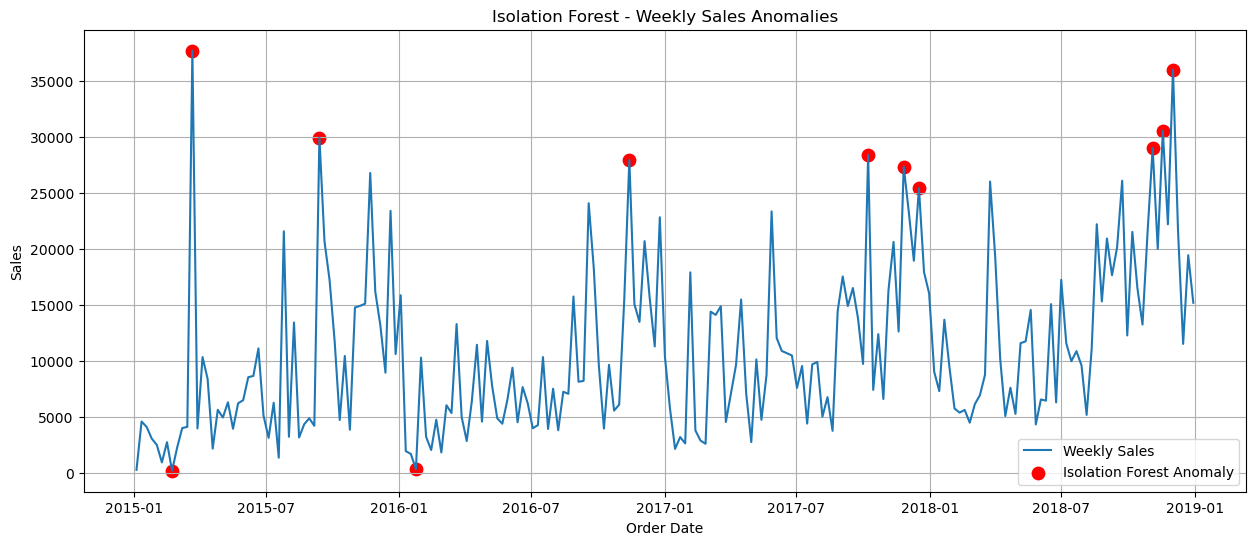

In [438]:
plt.figure(figsize=(15,6))
plt.plot(merged_weekly["Order Date"],merged_weekly["Sales"],label="Weekly Sales")
plt.scatter(merged_weekly.loc[merged_weekly["IF_Anomaly"],"Order Date"], merged_weekly.loc[merged_weekly["IF_Anomaly"],"Sales"],color="red",s=80, label="Isolation Forest Anomaly")
plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("isolation forest.jpg", dpi=300, bbox_inches="tight")
plt.show()

<br><h3> 3. For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")</h3>


<h2>Sales Anomaly Report</h2>
<table>
        <tr>
            <th>Order Date</th>
            <th>Sales ($)</th>
            <th>Possible Real-World Explanation</th>
        </tr>
        <tr>
            <td>04-Jan-2015</td>
            <td>304.51</td>
            <td>Very low sales, possibly due to the post-holiday slowdown or low customer activity.</td>
        </tr>
        <tr>
            <td>08-Feb-2015</td>
            <td>968.53</td>
            <td>Lower-than-normal sales, which could be caused by reduced demand or temporary operational issues.</td>
        </tr>
        <tr>
            <td>22-Feb-2015</td>
            <td>224.91</td>
            <td>Extremely low sales, possibly because of inventory shortages or fewer customer purchases.</td>
        </tr>
        <tr>
            <td>22-Mar-2015</td>
            <td>37,703.67</td>
            <td>Exceptional sales spike, likely due to a major promotional campaign, seasonal demand, or bulk corporate orders.</td>
        </tr>
        <tr>
            <td>19-Jul-2015</td>
            <td>1,387.69</td>
            <td>Unusually low sales, possibly reflecting an off-season period.</td>
        </tr>
        <tr>
            <td>13-Sep-2015</td>
            <td>29,959.14</td>
            <td>Significant increase in sales, possibly due to discounts or festive shopping.</td>
        </tr>
        <tr>
            <td>24-Jan-2016</td>
            <td>358.52</td>
            <td>Very low sales after the holiday season.</td>
        </tr>
        <tr>
            <td>17-Dec-2017</td>
            <td>25,449.80</td>
            <td>High sales likely driven by Christmas and year-end shopping.</td>
        </tr>
        <tr>
            <td>04-Nov-2018</td>
            <td>29,017.47</td>
            <td>Sales spike possibly associated with festive season promotions.</td>
        </tr>
        <tr>
            <td>18-Nov-2018</td>
            <td>30,572.45</td>
            <td>Increased demand during the pre-holiday shopping period.</td>
        </tr>
        <tr>
            <td>02-Dec-2018</td>
            <td>35,998.90</td>
            <td>Strong holiday shopping demand leading to exceptionally high sales.</td>
        </tr>
</table>

<br><h3>4. Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean</h3>

In [439]:
window = 8
merged_weekly["Rolling_Mean"] = (merged_weekly["Sales"].rolling(window).mean())
merged_weekly["Rolling_STD"] = (merged_weekly["Sales"].rolling(window).std())
merged_weekly["Z_Score"] = ((merged_weekly["Sales"]-merged_weekly["Rolling_Mean"])/merged_weekly["Rolling_STD"])
merged_weekly["Z_Anomaly"] = (abs(merged_weekly["Z_Score"] > 2))

print(merged_weekly[merged_weekly["Z_Anomaly"]][["Order Date","Sales","Z_Score"]])

    Order Date      Sales   Z_Score
11  2015-03-22  37703.665  2.460650
29  2015-07-26  21590.080  2.136467
86  2016-08-28  15773.478  2.053924
89  2016-09-18  24095.960  2.122082
125 2017-05-28  23367.662  2.008225
168 2018-03-25  26029.904  2.435627


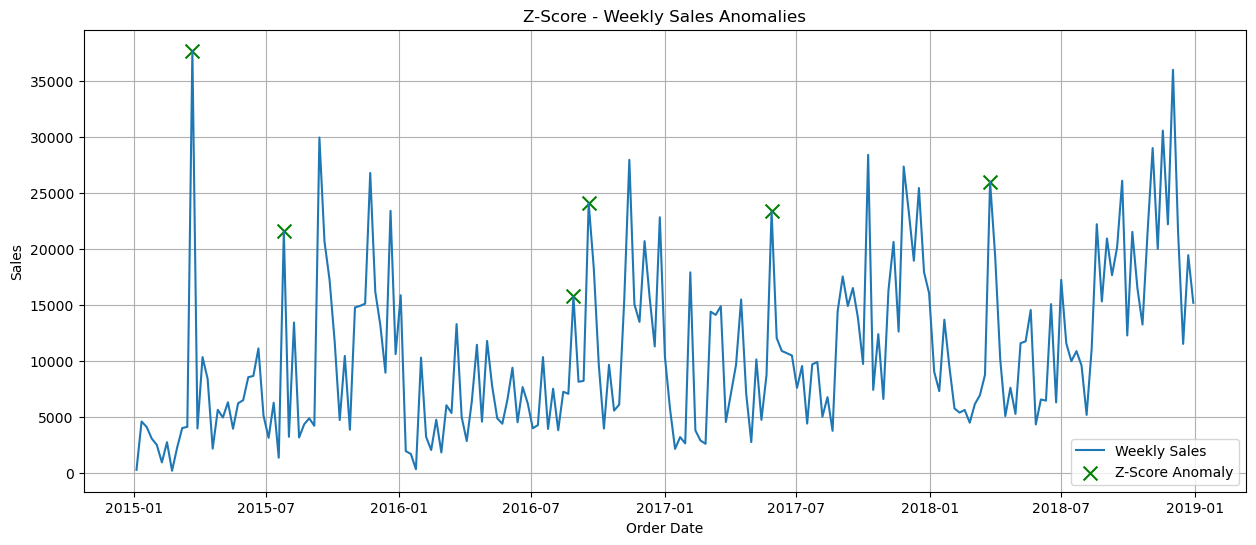

In [440]:
plt.figure(figsize=(15,6))
plt.plot(merged_weekly["Order Date"],merged_weekly["Sales"],label="Weekly Sales")
plt.scatter(merged_weekly.loc[merged_weekly["Z_Anomaly"],"Order Date"],merged_weekly.loc[merged_weekly["Z_Anomaly"],"Sales"],color="green", marker="x",s=100,label="Z-Score Anomaly")
plt.title("Z-Score - Weekly Sales Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("zscore.jpg", dpi=300, bbox_inches="tight")
plt.show()

<h2>Weekly Sales Anomaly Report</h2>

<table><thead>
        <tr>
            <th>Order Date</th>
            <th>Sales ($)</th>
            <th>Possible Real-World Explanation</th>
        </tr>
    </thead><tbody>
        <tr>
            <td>22-Mar-2015</td>
            <td>37,703.67</td>
            <td>Major promotional campaign or seasonal sales event.</td>
        </tr>
        <tr>
            <td>26-Jul-2015</td>
            <td>21,590.08</td>
            <td>Higher-than-usual sales compared to recent weeks.</td>
        </tr>
        <tr>
            <td>28-Aug-2016</td>
            <td>15,773.48</td>
            <td>Sudden increase in customer demand.</td>
        </tr>
        <tr>
            <td>18-Sep-2016</td>
            <td>24,095.96</td>
            <td>Promotional offers or seasonal buying trend.</td>
        </tr>
        <tr>
            <td>28-May-2017</td>
            <td>23,367.66</td>
            <td>Significant increase in weekly sales, possibly due to special discounts.</td>
        </tr>
        <tr>
            <td>25-Mar-2018</td>
            <td>26,029.90</td>
            <td>High sales likely resulting from promotional activities or seasonal demand.</td>
        </tr>
    </tbody>
</table>


<br><h3> 5. Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you? </h3>

In [441]:
print("Isolation Forest Anomalies")
print(merged_weekly[merged_weekly["IF_Anomaly"]][["Order Date","Sales"]])
#  flag any week where sales deviate more than 2 standard deviations from the rolling mean - The Z-Score method compares each week's sales with the average sales of the previous eight weeks. If a week's sales are more than two standard deviations above or below the rolling mean, the week is flagged as an anomaly.
print("\n Z-Score Anomalies")
print(merged_weekly[merged_weekly["Z_Anomaly"]][["Order Date","Sales"]])

Isolation Forest Anomalies
    Order Date       Sales
7   2015-02-22    224.9120
11  2015-03-22  37703.6650
36  2015-09-13  29959.1370
55  2016-01-24    358.5220
97  2016-11-13  27965.3492
144 2017-10-08  28412.0980
151 2017-11-26  27367.7160
154 2017-12-17  25449.8000
200 2018-11-04  29017.4670
202 2018-11-18  30572.4470
204 2018-12-02  35998.9000

 Z-Score Anomalies
    Order Date      Sales
11  2015-03-22  37703.665
29  2015-07-26  21590.080
86  2016-08-28  15773.478
89  2016-09-18  24095.960
125 2017-05-28  23367.662
168 2018-03-25  26029.904


In [442]:
common = pd.merge(merged_weekly[merged_weekly["IF_Anomaly"]][["Order Date","Sales"]],merged_weekly[merged_weekly["Z_Anomaly"]][["Order Date","Sales"]],on=["Order Date","Sales"])
print("Common Anomalies")
print(common)

Common Anomalies
  Order Date      Sales
0 2015-03-22  37703.665


Both anomaly detection methods identified 22 March 2015 as an anomalous sales week. This indicates that the sales during this week were significantly different from the normal sales pattern. The exceptionally high sales could be due to a major promotional campaign, seasonal demand, or bulk customer purchases. Although Isolation Forest detected additional high and low sales anomalies, the Z-Score method identified only the most statistically significant deviations. This suggests that Isolation Forest is more sensitive to unusual patterns, while the Z-Score method is stricter and focuses on extreme deviations from the rolling average.<hr>

<br><h2>Task 6 : Product Demand Segmentation using Clustering</h2>

<br><h3>1. Aggregate data at the product sub-category level with features like:<br>

Total sales volume<br>

Sales growth rate (year-over-year)<br>

Sales volatility (standard deviation of monthly sales)<br>

Average order value
</h3>

In [443]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [444]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Sub-Category                                       Product Name     Sales  \
0    Bookcases           

In [445]:
total_sales = (df.groupby("Sub-Category")["Sales"].sum())
print("Total Sales Volume")
print(total_sales)

Total Sales Volume
Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


In [446]:
yearly_sales = (df.groupby(["Sub-Category","Year"])["Sales"].sum().reset_index())
print(yearly_sales.head())

  Sub-Category  Year      Sales
0  Accessories  2015  23766.396
1  Accessories  2016  40443.970
2  Accessories  2017  41735.364
3  Accessories  2018  58240.970
4   Appliances  2015  15160.715


In [447]:
yearly_sales["Growth"] = (yearly_sales.groupby("Sub-Category")["Sales"].pct_change())
growth_rate = (yearly_sales.groupby("Sub-Category")["Growth"].mean())
print("Growth Rate")
print(growth_rate)

Growth Rate
Sub-Category
Accessories    0.376381
Appliances     0.399276
Art            0.166056
Binders        0.218736
Bookcases      0.238065
Chairs         0.071358
Copiers        0.846718
Envelopes     -0.027666
Fasteners      0.157034
Furnishings    0.287889
Labels         0.121927
Machines       0.080060
Paper          0.254131
Phones         0.123409
Storage        0.131799
Supplies       1.928448
Tables         0.164107
Name: Growth, dtype: float64


In [448]:
monthly_sales = (df.groupby(["Sub-Category","Month"])["Sales"].sum().reset_index())
print(monthly_sales.head())

  Sub-Category  Month     Sales
0  Accessories      1  5305.986
1  Accessories      2  5369.276
2  Accessories      3  8615.438
3  Accessories      4  7729.418
4  Accessories      5  9421.132


In [449]:
volatility = (monthly_sales.groupby("Sub-Category")["Sales"].std())
print("Sales Volatility")
print(volatility)

Sales Volatility
Sub-Category
Accessories     7951.755482
Appliances      5044.233502
Art              986.441037
Binders         9473.654328
Bookcases       6806.058624
Chairs         15998.986639
Copiers        11008.927684
Envelopes        744.501298
Fasteners        147.880694
Furnishings     4360.480255
Labels           532.798925
Machines       10541.342149
Paper           3231.953258
Phones         12493.977296
Storage         9145.871653
Supplies        3493.044662
Tables         10137.492404
Name: Sales, dtype: float64


In [450]:
avg_order = (df.groupby("Sub-Category")["Sales"].mean())
print("Average Order Value")
print(avg_order)

Average Order Value
Sub-Category
Accessories     217.178175
Appliances      227.926804
Art              34.019631
Binders         134.067550
Bookcases       503.598224
Chairs          531.833165
Copiers        2215.880212
Envelopes        65.032444
Fasteners        14.027850
Furnishings      95.823865
Labels           34.587468
Machines       1645.553313
Paper            57.420257
Phones          374.180877
Storage         263.633885
Supplies        252.284283
Tables          645.893720
Name: Sales, dtype: float64


In [451]:
features = pd.DataFrame({"Total_Sales": total_sales,"Growth_Rate": growth_rate,"Volatility": volatility,    "Avg_Order_Value": avg_order})
features = features.fillna(0)
print(features)

              Total_Sales  Growth_Rate    Volatility  Avg_Order_Value
Sub-Category                                                         
Accessories   164186.7000     0.376381   7951.755482       217.178175
Appliances    104618.4030     0.399276   5044.233502       227.926804
Art            26705.4100     0.166056    986.441037        34.019631
Binders       200028.7850     0.218736   9473.654328       134.067550
Bookcases     113813.1987     0.238065   6806.058624       503.598224
Chairs        322822.7310     0.071358  15998.986639       531.833165
Copiers       146248.0940     0.846718  11008.927684      2215.880212
Envelopes      16128.0460    -0.027666    744.501298        65.032444
Fasteners       3001.9600     0.157034    147.880694        14.027850
Furnishings    89212.0180     0.287889   4360.480255        95.823865
Labels         12347.7260     0.121927    532.798925        34.587468
Machines      189238.6310     0.080060  10541.342149      1645.553313
Paper          76828

In [452]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print(scaled_features)

[[ 0.31598599  0.11450548  0.29509404 -0.36354857]
 [-0.28817617  0.16628324 -0.33686397 -0.34520236]
 [-1.07839653 -0.36114889 -1.21883647 -0.67617125]
 [ 0.67950874 -0.24201087  0.625883   -0.50540527]
 [-0.19491939 -0.19829775  0.04607363  0.12532518]
 [ 1.92492716 -0.57530937  2.04418217  0.17351776]
 [ 0.13404648  1.17818256  0.95957894  3.04791985]
 [-1.18567579 -0.79925477 -1.27142275 -0.62323728]
 [-1.31880507 -0.38155164 -1.4010999  -0.71029406]
 [-0.44443302 -0.08561934 -0.48547964 -0.57068119]
 [-1.2240171  -0.46094751 -1.31743685 -0.67520204]
 [ 0.57007129 -0.5556294   0.85794792  2.07446199]
 [-0.57003291 -0.16196515 -0.73076813 -0.63623008]
 [ 1.97523032 -0.45759532  1.28235861 -0.09556978]
 [ 0.87540412 -0.43862129  0.55463852 -0.28425602]
 [-0.87844126  3.6245359  -0.67401919 -0.30362799]
 [ 0.70772315 -0.36555587  0.77017005  0.36820109]]


<br><h3>2. Use the Elbow Method to find the optimal number of clusters </h3>

In [453]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
print("WCSS Values")
print(wcss)

C:\Users\Mansi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Mansi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Mansi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Mansi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

WCSS Values
[68.00000000000001, 37.89581929913348, 24.236527804519827, 12.063767821923769, 7.0680944065395295, 4.341028364677348, 2.2639430730522543, 1.543896554614712, 1.1391804658584392, 0.7959217307567144]


C:\Users\Mansi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


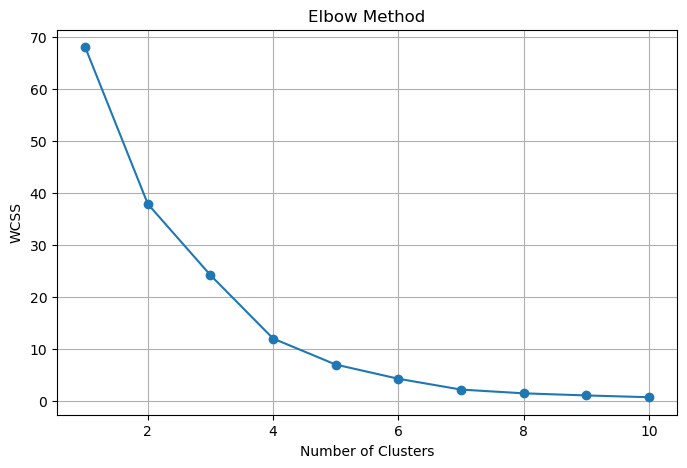

In [454]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("elbow.jpg", dpi=300, bbox_inches="tight")
plt.show()

<br><h3>3. Apply K-Means Clustering to segment products into demand groups
</h3>

In [455]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
features["Cluster"] = kmeans.fit_predict(scaled_features)
print(features)

              Total_Sales  Growth_Rate    Volatility  Avg_Order_Value  Cluster
Sub-Category                                                                  
Accessories   164186.7000     0.376381   7951.755482       217.178175        2
Appliances    104618.4030     0.399276   5044.233502       227.926804        1
Art            26705.4100     0.166056    986.441037        34.019631        1
Binders       200028.7850     0.218736   9473.654328       134.067550        2
Bookcases     113813.1987     0.238065   6806.058624       503.598224        1
Chairs        322822.7310     0.071358  15998.986639       531.833165        2
Copiers       146248.0940     0.846718  11008.927684      2215.880212        0
Envelopes      16128.0460    -0.027666    744.501298        65.032444        1
Fasteners       3001.9600     0.157034    147.880694        14.027850        1
Furnishings    89212.0180     0.287889   4360.480255        95.823865        1
Labels         12347.7260     0.121927    532.798925

C:\Users\Mansi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<br><h3> 5. Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed) </h3>

In [456]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)
features["PC1"] = principal_components[:,0]
features["PC2"] = principal_components[:,1]
print(features)

              Total_Sales  Growth_Rate    Volatility  Avg_Order_Value  \
Sub-Category                                                            
Accessories   164186.7000     0.376381   7951.755482       217.178175   
Appliances    104618.4030     0.399276   5044.233502       227.926804   
Art            26705.4100     0.166056    986.441037        34.019631   
Binders       200028.7850     0.218736   9473.654328       134.067550   
Bookcases     113813.1987     0.238065   6806.058624       503.598224   
Chairs        322822.7310     0.071358  15998.986639       531.833165   
Copiers       146248.0940     0.846718  11008.927684      2215.880212   
Envelopes      16128.0460    -0.027666    744.501298        65.032444   
Fasteners       3001.9600     0.157034    147.880694        14.027850   
Furnishings    89212.0180     0.287889   4360.480255        95.823865   
Labels         12347.7260     0.121927    532.798925        34.587468   
Machines      189238.6310     0.080060  10541.34214

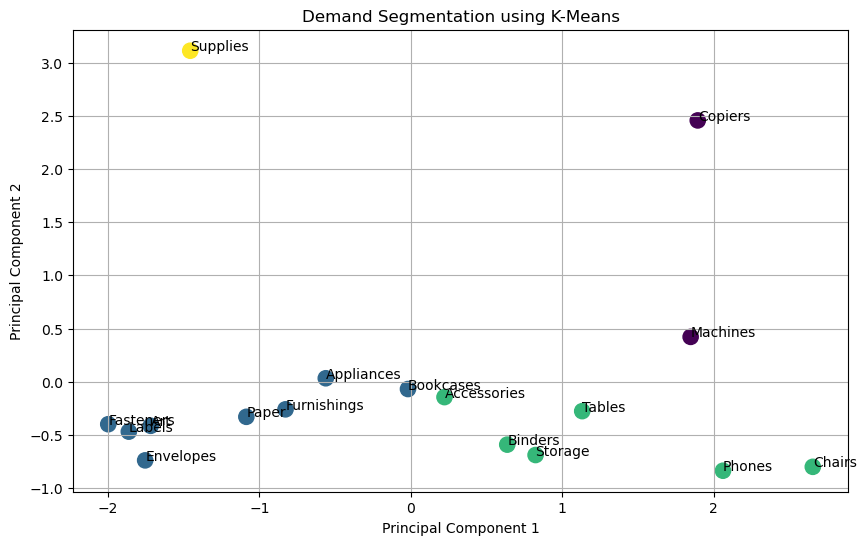

In [457]:
plt.figure(figsize=(10,6))
plt.scatter(features["PC1"],features["PC2"],c=features["Cluster"],s=120)
for i in range(len(features)):
    plt.text(features["PC1"].iloc[i],features["PC2"].iloc[i],features.index[i])
plt.title("Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.savefig("features.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [458]:
cluster_summary = (features.groupby("Cluster")[["Total_Sales", "Growth_Rate","Volatility","Avg_Order_Value"]].mean())
print(cluster_summary)

           Total_Sales  Growth_Rate    Volatility  Avg_Order_Value
Cluster                                                           
0        167743.362500     0.463389  10775.134917      1930.716763
1         55331.883212     0.199589   2731.793449       129.054568
2        239495.780667     0.180965  10866.956300       361.131228
3         46420.308000     1.928448   3493.044662       252.284283


<br>
<h3>4. Label each cluster meaningfully, for example:<br>
<br>
High Volume, Stable Demand<br>
<br>
Low Volume, High Volatility<br>
<br>
Growing Demand<br>
<br>
Declining Demand<br.</h3>


In [459]:
cluster_names = {
    0: "Low Volume, High Volatility",
    1: "Declining Demand",
    2: "High Volume, Stable Demand",
    3: "Growing Demand"
}
features["Demand_Group"] = features["Cluster"].map(cluster_names)
print(features[["Cluster","Demand_Group"]])

              Cluster                 Demand_Group
Sub-Category                                      
Accessories         2   High Volume, Stable Demand
Appliances          1             Declining Demand
Art                 1             Declining Demand
Binders             2   High Volume, Stable Demand
Bookcases           1             Declining Demand
Chairs              2   High Volume, Stable Demand
Copiers             0  Low Volume, High Volatility
Envelopes           1             Declining Demand
Fasteners           1             Declining Demand
Furnishings         1             Declining Demand
Labels              1             Declining Demand
Machines            0  Low Volume, High Volatility
Paper               1             Declining Demand
Phones              2   High Volume, Stable Demand
Storage             2   High Volume, Stable Demand
Supplies            3               Growing Demand
Tables              2   High Volume, Stable Demand


| Cluster       | Demand Group                    | Products                                                                     | Recommended Stocking Strategy                                                                                                                                                |
| ------------- | ------------------------------- | ---------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Cluster 0** | **Low Volume, High Volatility** | Copiers, Machines                                                            | Keep limited inventory with a small safety stock. Monitor demand frequently and replenish only when necessary to avoid overstocking expensive and unpredictable products.    |
| **Cluster 1** | **Declining Demand**            | Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper | Reduce inventory levels and avoid excessive stock. Use discounts, promotions, or bundle offers to clear slow-moving items while maintaining only essential inventory.        |
| **Cluster 2** | **High Volume, Stable Demand**  | Accessories, Binders, Chairs, Phones, Storage, Tables                        | Maintain higher inventory levels and automate replenishment. Since these products have consistent demand, ensure sufficient stock is always available to prevent stock-outs. |
| **Cluster 3** | **Growing Demand**              | Supplies                                                                     | Gradually increase inventory based on the rising sales trend. Monitor demand closely and adjust stock levels regularly to support future growth without overstocking.        |
